In [21]:
# import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

In [22]:
students_df = pd.read_csv("student_grade_predictor.csv")

In [23]:
print(students_df[['PreviousGrade', 'FinalGrade']].corr())

               PreviousGrade  FinalGrade
PreviousGrade       1.000000    0.997134
FinalGrade          0.997134    1.000000


In [24]:
students_df.drop(['Name','StudentID'],axis = 1, inplace = True)

In [25]:
students_df.isnull().sum()

Gender                       0
AttendanceRate               0
StudyHoursPerWeek            0
PreviousGrade                0
ExtracurricularActivities    0
ParentalSupport              0
FinalGrade                   0
Study Hours                  0
Attendance (%)               0
Online Classes Taken         0
dtype: int64

In [26]:
students_df.dropna(subset=["FinalGrade"], inplace=True)

In [27]:
# Remove negative value
students_df = students_df[students_df['Study Hours'] >= 0]

In [28]:
encoder = OneHotEncoder(
    sparse_output=False,
    drop='first'
)
cat_cols = [
    'Gender',
    'ExtracurricularActivities',
    'ParentalSupport',
]
encoded_data = encoder.fit_transform(students_df[cat_cols])

encoded_df = pd.DataFrame(
    encoded_data,
    columns=encoder.get_feature_names_out(cat_cols)
)

students_df = pd.concat(
    [students_df.drop(columns=cat_cols).reset_index(drop=True),
     encoded_df.reset_index(drop=True)],
    axis=1
)

In [32]:
students_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 11 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   AttendanceRate                 100 non-null    int64  
 1   StudyHoursPerWeek              100 non-null    int64  
 2   PreviousGrade                  100 non-null    int64  
 3   FinalGrade                     100 non-null    int64  
 4   Study Hours                    100 non-null    int64  
 5   Attendance (%)                 100 non-null    int64  
 6   Online Classes Taken           100 non-null    int64  
 7   Gender_Male                    100 non-null    float64
 8   ExtracurricularActivities_Yes  100 non-null    float64
 9   ParentalSupport_Low            100 non-null    float64
 10  ParentalSupport_Medium         100 non-null    float64
dtypes: float64(4), int64(7)
memory usage: 8.7 KB


In [38]:
x = students_df.drop(['FinalGrade'], axis=1)
y = students_df['FinalGrade']

In [39]:
print(students_df.shape)

print(students_df.corr(numeric_only=True)['FinalGrade']
      .sort_values(ascending=False))

(100, 11)
FinalGrade                       1.000000
AttendanceRate                   0.998355
Attendance (%)                   0.998355
PreviousGrade                    0.997134
StudyHoursPerWeek                0.971280
Study Hours                      0.971280
Online Classes Taken             0.959511
ExtracurricularActivities_Yes    0.882086
ParentalSupport_Medium           0.112381
Gender_Male                     -0.864232
ParentalSupport_Low             -0.871396
Name: FinalGrade, dtype: float64


In [40]:
# train test split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [41]:
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [42]:
model = LinearRegression()

model.fit(x_train_scaled, y_train)

y_pred = model.predict(x_test_scaled)

In [43]:
print(f"R2 Score: {r2_score(y_test, y_pred)}")

R2 Score: 0.9993523243244609


In [44]:
print(f"MSE: {mean_squared_error(y_test, y_pred)}")

MSE: 0.2045295015785123


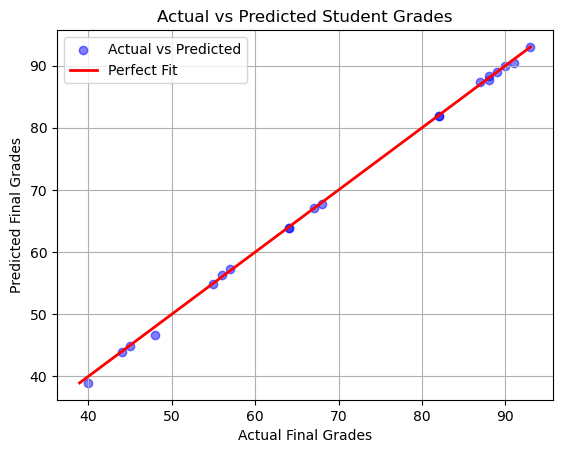

In [46]:
plt.scatter(y_test, y_pred, color='blue', alpha=0.5, label='Actual vs Predicted');
max_val = max(max(y_test), max(y_pred))
min_val = min(min(y_test), min(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', lw=2, label='Perfect Fit')
plt.xlabel('Actual Final Grades')
plt.ylabel('Predicted Final Grades')
plt.title('Actual vs Predicted Student Grades')
plt.legend()
plt.grid(True)
plt.show()